# CNN Hyperparameter Search

## 1. Setup repo i środowiska

In [1]:
REPO_URL = "https://github.com/tsmyda/cnn-metaheuristics.git"
PROJECT_DIR = "/content/cnn-metaheuristics"

%cd /content
!rm -rf {PROJECT_DIR}
!git clone {REPO_URL} {PROJECT_DIR}
%cd {PROJECT_DIR}
!pip install -q -r requirements.txt

/content
Cloning into '/content/cnn-metaheuristics'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 35 (delta 9), reused 33 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (35/35), 12.61 KiB | 12.61 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/cnn-metaheuristics


## 2. Importy

In [2]:
import os
import sys
import importlib

sys.path.insert(0, "/content/cnn-metaheuristics")

import torch
import pandas as pd
import matplotlib.pyplot as plt

import src.utils
import src.search_space
import src.evaluator
import src.plots
import src.algorithms.manual_search
import src.algorithms.random_search
import src.algorithms.ga
import src.algorithms.pso

importlib.reload(src.utils)
importlib.reload(src.search_space)
importlib.reload(src.evaluator)
importlib.reload(src.plots)
importlib.reload(src.algorithms.manual_search)
importlib.reload(src.algorithms.random_search)
importlib.reload(src.algorithms.ga)
importlib.reload(src.algorithms.pso)

from src.utils import set_seed, ensure_dir
from src.algorithms.manual_search import run_manual_search
from src.algorithms.random_search import run_random_search
from src.algorithms.ga import run_ga
from src.algorithms.pso import run_pso
from src.plots import plot_best_so_far, save_summary_table

set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 3. Parametry eksperymentu

In [3]:
DATASET = "FashionMNIST"
SEED = 42
EPOCHS = 5

RANDOM_BUDGET = 20

GA_POPULATION = 5
GA_GENERATIONS = 4
GA_MUTATION_PROB = 0.20
GA_ELITE_SIZE = 1
GA_TOURNAMENT_SIZE = 3

PSO_SWARM = 5
PSO_ITERATIONS = 4
PSO_W = 0.7
PSO_C1 = 1.5
PSO_C2 = 1.5

assert RANDOM_BUDGET == GA_POPULATION * GA_GENERATIONS, "GA budget should match random search budget"
assert RANDOM_BUDGET == PSO_SWARM * PSO_ITERATIONS, "PSO budget should match random search budget"

RESULTS_DIR = "results"
TABLES_DIR = os.path.join(RESULTS_DIR, "tables")
FIGURES_DIR = os.path.join(RESULTS_DIR, "figures")

ensure_dir(RESULTS_DIR)
ensure_dir(TABLES_DIR)
ensure_dir(FIGURES_DIR)

print("Dataset:", DATASET)
print("Seed:", SEED)
print("Epochs per evaluation:", EPOCHS)
print("Random budget:", RANDOM_BUDGET)
print("GA budget:", GA_POPULATION * GA_GENERATIONS)
print("PSO budget:", PSO_SWARM * PSO_ITERATIONS)

Dataset: FashionMNIST
Seed: 42
Epochs per evaluation: 5
Random budget: 20
GA budget: 20
PSO budget: 20


## 4. Sanity check losowania

In [4]:
from src.search_space import sample_config

for i in range(3):
    print(f"sample {i+1}:", sample_config())

sample 1: {'learning_rate': 0.0019004375238737116, 'batch_size': 32, 'num_blocks': 3, 'filters_1': 32, 'filters_2': 32, 'filters_3': 64, 'kernel_size': 3, 'dropout': 0.3682356070820062, 'dense_units': 256}
sample 2: {'learning_rate': 0.0030292526001368903, 'batch_size': 32, 'num_blocks': 3, 'filters_1': 32, 'filters_2': 32, 'filters_3': 64, 'kernel_size': 3, 'dropout': 0.10931898740180168, 'dense_units': 256}
sample 3: {'learning_rate': 0.0015996959971844033, 'batch_size': 64, 'num_blocks': 3, 'filters_1': 64, 'filters_2': 128, 'filters_3': 256, 'kernel_size': 5, 'dropout': 0.11022031102034835, 'dense_units': 256}


## 5. Manual search

In [5]:
best_manual, df_manual = run_manual_search(
    dataset_name=DATASET,
    epochs=EPOCHS,
    device=device,
    seed=SEED,
)

print("Best manual config:")
print(best_manual)
df_manual.head()

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 170kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.20MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.9MB/s]


[MANUAL] iter=01/5 | val_acc=0.9177 | time=60.8s
[MANUAL] iter=02/5 | val_acc=0.9033 | time=41.4s
[MANUAL] iter=03/5 | val_acc=0.9088 | time=54.7s
[MANUAL] iter=04/5 | val_acc=0.8850 | time=56.8s
[MANUAL] iter=05/5 | val_acc=0.9228 | time=67.8s
Best manual config:
{'learning_rate': 0.0008, 'batch_size': 32, 'num_blocks': 1, 'filters_1': 32, 'filters_2': 64, 'filters_3': 128, 'kernel_size': 5, 'dropout': 0.2, 'dense_units': 128}


,method,iteration,learning_rate,batch_size,num_blocks,filters_1,filters_2,filters_3,kernel_size,dropout,dense_units,val_accuracy,val_loss,test_accuracy,test_loss,time_sec,num_params
0,manual_search,1,0.0010,64,2,32,64,128,3,0.25,128,0.917667,0.223847,0.9120,0.234021,60.778181,467818
1,manual_search,2,0.0005,128,2,32,64,128,3,0.30,256,0.903333,0.257479,0.9026,0.263356,41.443677,870634
2,manual_search,3,0.0010,64,3,32,64,128,3,0.35,128,0.908833,0.246423,0.9028,0.263255,54.711487,435306
3,manual_search,4,0.0002,128,3,64,128,256,3,0.40,256,0.885000,0.315185,0.8789,0.324865,56.796756,1736906
4,manual_search,5,0.0008,32,1,32,64,128,5,0.20,128,0.922833,0.217359,0.9205,0.223954,67.795626,830698


## 6. Random search

In [6]:
best_random, df_random = run_random_search(
    dataset_name=DATASET,
    budget=RANDOM_BUDGET,
    epochs=EPOCHS,
    device=device,
    seed=SEED,
)

print("Best random config:")
print(best_random)

df_random[[
    "iteration",
    "learning_rate",
    "batch_size",
    "num_blocks",
    "filters_1",
    "filters_2",
    "filters_3",
    "kernel_size",
    "dropout",
    "dense_units",
    "val_accuracy",
]].head()

[RS] iter=01/20 | val_acc=0.9260 | time=68.7s
[RS] iter=02/20 | val_acc=0.8820 | time=36.7s
[RS] iter=03/20 | val_acc=0.9157 | time=94.5s
[RS] iter=04/20 | val_acc=0.8755 | time=51.7s
[RS] iter=05/20 | val_acc=0.8833 | time=53.3s
[RS] iter=06/20 | val_acc=0.8962 | time=62.1s
[RS] iter=07/20 | val_acc=0.8902 | time=55.3s
[RS] iter=08/20 | val_acc=0.9072 | time=68.4s
[RS] iter=09/20 | val_acc=0.8988 | time=40.5s
[RS] iter=10/20 | val_acc=0.9042 | time=37.6s
[RS] iter=11/20 | val_acc=0.1022 | time=56.6s
[RS] iter=12/20 | val_acc=0.1097 | time=45.1s
[RS] iter=13/20 | val_acc=0.9198 | time=41.0s
[RS] iter=14/20 | val_acc=0.0997 | time=63.7s
[RS] iter=15/20 | val_acc=0.9207 | time=52.2s
[RS] iter=16/20 | val_acc=0.8532 | time=41.9s
[RS] iter=17/20 | val_acc=0.9187 | time=51.7s
[RS] iter=18/20 | val_acc=0.9110 | time=103.0s
[RS] iter=19/20 | val_acc=0.8952 | time=37.8s
[RS] iter=20/20 | val_acc=0.9057 | time=54.6s
Best random config:
{'learning_rate': 0.00036006542157995136, 'batch_size': 32,

,iteration,learning_rate,batch_size,num_blocks,filters_1,filters_2,filters_3,kernel_size,dropout,dense_units,val_accuracy
0,1,0.000360,32,1,64,64,128,5,0.077740,128,0.926000
1,2,0.000160,256,1,32,64,256,5,0.403564,256,0.882000
2,3,0.000830,32,2,16,128,128,5,0.288676,256,0.915667
3,4,0.000138,64,2,16,32,64,5,0.138987,256,0.875500
4,5,0.004658,64,2,32,32,256,5,0.350910,256,0.883333


## 7. Genetic Algorithm

In [7]:
best_ga, df_ga = run_ga(
    dataset_name=DATASET,
    population_size=GA_POPULATION,
    generations=GA_GENERATIONS,
    epochs=EPOCHS,
    device=device,
    seed=SEED,
    mutation_prob=GA_MUTATION_PROB,
    elite_size=GA_ELITE_SIZE,
    tournament_size=GA_TOURNAMENT_SIZE,
)

print("Best GA config:")
print(best_ga)

df_ga[[
    "iteration",
    "generation",
    "learning_rate",
    "batch_size",
    "num_blocks",
    "filters_1",
    "filters_2",
    "filters_3",
    "kernel_size",
    "dropout",
    "dense_units",
    "val_accuracy",
]].head()

[GA] gen=01/4 | ind=01/5 | val_acc=0.8407 | best=0.8407
[GA] gen=01/4 | ind=02/5 | val_acc=0.9205 | best=0.9205
[GA] gen=01/4 | ind=03/5 | val_acc=0.8990 | best=0.9205
[GA] gen=01/4 | ind=04/5 | val_acc=0.9100 | best=0.9205
[GA] gen=01/4 | ind=05/5 | val_acc=0.9128 | best=0.9205
[GA] gen=02/4 | ind=01/5 | val_acc=0.9205 | best=0.9205
[GA] gen=02/4 | ind=02/5 | val_acc=0.8985 | best=0.9205
[GA] gen=02/4 | ind=03/5 | val_acc=0.8858 | best=0.9205
[GA] gen=02/4 | ind=04/5 | val_acc=0.8970 | best=0.9205
[GA] gen=02/4 | ind=05/5 | val_acc=0.9118 | best=0.9205
[GA] gen=03/4 | ind=01/5 | val_acc=0.9205 | best=0.9205
[GA] gen=03/4 | ind=02/5 | val_acc=0.9205 | best=0.9205
[GA] gen=03/4 | ind=03/5 | val_acc=0.9205 | best=0.9205
[GA] gen=03/4 | ind=04/5 | val_acc=0.9187 | best=0.9205
[GA] gen=03/4 | ind=05/5 | val_acc=0.9063 | best=0.9205
[GA] gen=04/4 | ind=01/5 | val_acc=0.9205 | best=0.9205
[GA] gen=04/4 | ind=02/5 | val_acc=0.9228 | best=0.9228
[GA] gen=04/4 | ind=03/5 | val_acc=0.9158 | best

,iteration,generation,learning_rate,batch_size,num_blocks,filters_1,filters_2,filters_3,kernel_size,dropout,dense_units,val_accuracy
0,1,1,0.005239,32,3,16,64,256,5,0.107118,64,0.840667
1,2,1,0.002797,256,1,32,64,64,3,0.048465,128,0.920500
2,3,1,0.000511,256,2,64,32,256,3,0.030306,256,0.899000
3,4,1,0.000477,32,1,16,32,256,5,0.070091,64,0.910000
4,5,1,0.000361,64,1,32,128,64,3,0.326072,256,0.912833


## 8. PSO

In [8]:
best_pso, df_pso = run_pso(
    dataset_name=DATASET,
    swarm_size=PSO_SWARM,
    iterations=PSO_ITERATIONS,
    epochs=EPOCHS,
    device=device,
    seed=SEED,
    w=PSO_W,
    c1=PSO_C1,
    c2=PSO_C2,
)

print("Best PSO config:")
print(best_pso)

df_pso[[
    "iteration",
    "pso_iteration",
    "particle",
    "learning_rate",
    "batch_size",
    "num_blocks",
    "filters_1",
    "filters_2",
    "filters_3",
    "kernel_size",
    "dropout",
    "dense_units",
    "val_accuracy",
]].head()

[PSO] iter=01/4 | particle=01/5 | val_acc=0.8687 | best=0.8687
[PSO] iter=01/4 | particle=02/5 | val_acc=0.8617 | best=0.8687
[PSO] iter=01/4 | particle=03/5 | val_acc=0.8885 | best=0.8885
[PSO] iter=01/4 | particle=04/5 | val_acc=0.9025 | best=0.9025
[PSO] iter=01/4 | particle=05/5 | val_acc=0.7842 | best=0.9025
[PSO] iter=02/4 | particle=01/5 | val_acc=0.8892 | best=0.9025
[PSO] iter=02/4 | particle=02/5 | val_acc=0.9198 | best=0.9198
[PSO] iter=02/4 | particle=03/5 | val_acc=0.8850 | best=0.9198
[PSO] iter=02/4 | particle=04/5 | val_acc=0.9043 | best=0.9198
[PSO] iter=02/4 | particle=05/5 | val_acc=0.9083 | best=0.9198
[PSO] iter=03/4 | particle=01/5 | val_acc=0.9147 | best=0.9198
[PSO] iter=03/4 | particle=02/5 | val_acc=0.9228 | best=0.9228
[PSO] iter=03/4 | particle=03/5 | val_acc=0.8995 | best=0.9228
[PSO] iter=03/4 | particle=04/5 | val_acc=0.9122 | best=0.9228
[PSO] iter=03/4 | particle=05/5 | val_acc=0.9218 | best=0.9228
[PSO] iter=04/4 | particle=01/5 | val_acc=0.9262 | best

,iteration,pso_iteration,particle,learning_rate,batch_size,num_blocks,filters_1,filters_2,filters_3,kernel_size,dropout,dense_units,val_accuracy
0,1,1,1,0.006430,64,2,64,64,128,3,0.324942,128,0.868667
1,2,1,2,0.008113,256,2,64,32,256,3,0.268114,128,0.861667
2,3,1,3,0.008311,256,2,32,32,64,3,0.185090,128,0.888500
3,4,1,4,0.006516,64,1,64,64,256,3,0.157727,128,0.902500
4,5,1,5,0.008776,128,3,32,64,128,3,0.498769,64,0.784167


## 9. Zapis wszystkich wyników

In [9]:
df_all = pd.concat([df_manual, df_random, df_ga, df_pso], ignore_index=True)

csv_path = os.path.join(TABLES_DIR, "all_methods_comparison.csv")
summary_path = os.path.join(TABLES_DIR, "all_methods_summary.csv")
figure_path = os.path.join(FIGURES_DIR, "best_so_far_all_methods.png")

df_all.to_csv(csv_path, index=False)
plot_best_so_far(csv_path, figure_path)
save_summary_table(csv_path, summary_path)

print("Saved full results to:", csv_path)
print("Saved summary to:", summary_path)
print("Saved figure to:", figure_path)

Saved full results to: results/tables/all_methods_comparison.csv
Saved summary to: results/tables/all_methods_summary.csv
Saved figure to: results/figures/best_so_far_all_methods.png


## 10. Tabela podsumowująca

In [10]:
summary_df = pd.read_csv(summary_path)
summary_df

,Unnamed: 0,val_accuracy,val_accuracy.1,test_accuracy,test_accuracy.1,time_sec,time_sec.1,num_params,num_params.1
0,NaN,max,mean,max,mean,max,mean,max,mean
1,method,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ga,0.9228,0.9091,0.921,0.9059,127.0464,46.3396,2331642,906488.4
3,manual_search,0.9228,0.9075,0.9205,0.9034,67.7956,56.3051,1736906,868272.4
4,pso,0.9262,0.9001,0.9224,0.8952,73.603,46.4567,1644618,1112952.4
5,random_search,0.926,0.7807,0.9159,0.7762,103.0137,55.822,3251658,951808.4


## 11. Najlepsze konfiguracje każdej metody

In [11]:
best_rows = (
    df_all.sort_values(["method", "val_accuracy"], ascending=[True, False])
    .groupby("method", as_index=False)
    .first()
)

cols = [
    "method",
    "iteration",
    "learning_rate",
    "batch_size",
    "num_blocks",
    "filters_1",
    "filters_2",
    "filters_3",
    "kernel_size",
    "dropout",
    "dense_units",
    "val_accuracy",
    "test_accuracy",
    "time_sec",
    "num_params",
]

best_rows[cols]

,method,iteration,learning_rate,batch_size,num_blocks,filters_1,filters_2,filters_3,kernel_size,dropout,dense_units,val_accuracy,test_accuracy,time_sec,num_params
0,ga,17,0.002797,128,1,32,64,64,3,0.048465,128,0.922833,0.9123,40.556986,813802
1,manual_search,5,0.000800,32,1,32,64,128,5,0.200000,128,0.922833,0.9205,67.795626,830698
2,pso,16,0.003198,128,1,64,128,256,3,0.160555,128,0.926167,0.9206,40.534181,1644618
3,random_search,1,0.000360,32,1,64,64,128,5,0.077740,128,0.926000,0.9159,68.682201,1711178


## 12. Wykres best-so-far

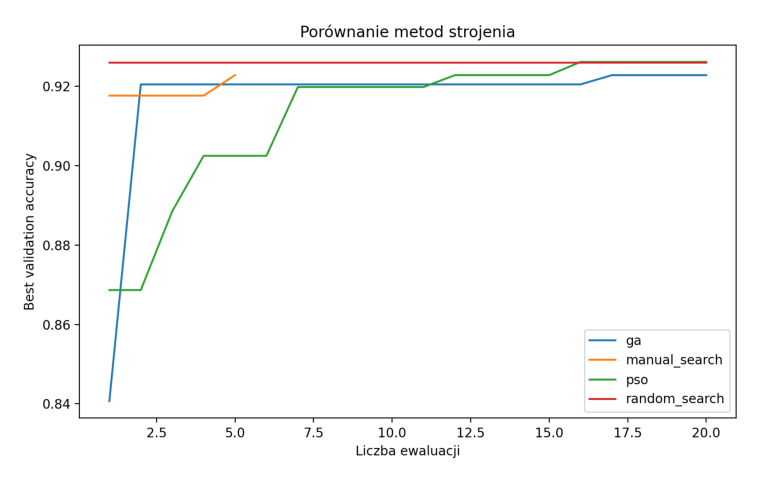

In [12]:
img = plt.imread(figure_path)
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

## 13. Dodatkowa analiza - średni czas i najlepsza jakość

In [13]:
analysis_df = (
    df_all.groupby("method", as_index=False)
    .agg(
        best_val_accuracy=("val_accuracy", "max"),
        mean_val_accuracy=("val_accuracy", "mean"),
        best_test_accuracy=("test_accuracy", "max"),
        mean_time_sec=("time_sec", "mean"),
        total_time_sec=("time_sec", "sum"),
        mean_num_params=("num_params", "mean"),
    )
    .sort_values("best_val_accuracy", ascending=False)
)

analysis_df

,method,best_val_accuracy,mean_val_accuracy,best_test_accuracy,mean_time_sec,total_time_sec,mean_num_params
2,pso,0.926167,0.900075,0.9224,46.456729,929.134573,1112952.4
3,random_search,0.926000,0.780733,0.9159,55.821988,1116.439757,951808.4
1,manual_search,0.922833,0.907533,0.9205,56.305145,281.525726,868272.4
0,ga,0.922833,0.909117,0.9210,46.339599,926.791974,906488.4


## 14. Zapis wyników na Google Drive

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# !mkdir -p /content/drive/MyDrive/cnn-metaheuristics-results
# !cp {csv_path} /content/drive/MyDrive/cnn-metaheuristics-results/
# !cp {summary_path} /content/drive/MyDrive/cnn-metaheuristics-results/
# !cp {figure_path} /content/drive/MyDrive/cnn-metaheuristics-results/

Mounted at /content/drive


## 15. Co dalej?

- Można podostrajać, zmienić parametry, dodać niektóre do przeszukiwanych przestrzeni nwm
- Chyba pasuje przetestować na innych zbiorach też

## 16. Zapis najlepszych konfiguracji do pliku

In [16]:
best_configs_path_csv = os.path.join(TABLES_DIR, "best_configs.csv")
best_configs_path_json = os.path.join(TABLES_DIR, "best_configs.json")

best_rows.to_csv(best_configs_path_csv, index=False)
best_rows.to_json(best_configs_path_json, orient="records", indent=2)

print("Saved best configs CSV to:", best_configs_path_csv)
print("Saved best configs JSON to:", best_configs_path_json)

Saved best configs CSV to: results/tables/best_configs.csv
Saved best configs JSON to: results/tables/best_configs.json


## 17. Wykres quality vs cumulative time

In [17]:
def plot_best_so_far_vs_time(df: pd.DataFrame, output_path: str):
    plt.figure(figsize=(8, 5))

    for method, group in df.groupby("method"):
        group = group.sort_values("iteration").copy()
        group["cum_time_sec"] = group["time_sec"].cumsum()
        group["best_so_far"] = group["val_accuracy"].cummax()
        plt.plot(group["cum_time_sec"], group["best_so_far"], label=method)

    plt.xlabel("Skumulowany czas [s]")
    plt.ylabel("Best validation accuracy")
    plt.title("Quality vs cumulative time")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.close()

figure_time_path = os.path.join(FIGURES_DIR, "best_so_far_vs_time.png")
plot_best_so_far_vs_time(df_all, figure_time_path)

print("Saved figure to:", figure_time_path)

Saved figure to: results/figures/best_so_far_vs_time.png


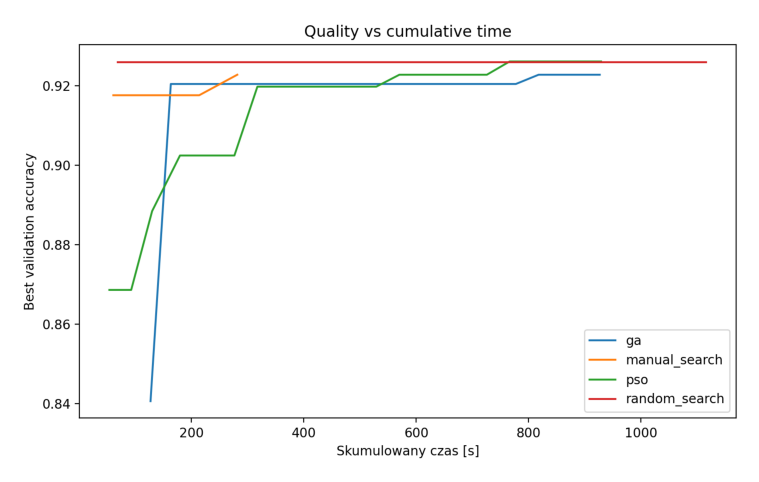

In [18]:
img = plt.imread(figure_time_path)
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

## 18. Final retraining najlepszych konfiguracji

In [ ]:
FINAL_EPOCHS = 20
FINAL_SEED = 42

print("Final retraining epochs:", FINAL_EPOCHS)

Final retraining epochs: 20


In [20]:
from src.datasets import get_dataset_loaders
from src.model import TunableCNN
from src.train import train_one_epoch, evaluate
from src.utils import count_parameters
from torch.optim import Adam

def retrain_best_config(
    config: dict,
    dataset_name: str,
    epochs: int,
    device: str,
    seed: int = 42,
    val_split: float = 0.1,
    num_workers: int = 2,
):
    import numpy as np
    import torch

    # deterministyczność dla finalnego treningu
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    train_loader, val_loader, test_loader, image_channels, image_size, num_classes = get_dataset_loaders(
        dataset_name=dataset_name,
        batch_size=int(config["batch_size"]),
        val_split=val_split,
        num_workers=num_workers,
        seed=seed,
    )

    model = TunableCNN(
        image_channels=image_channels,
        image_size=image_size,
        num_classes=num_classes,
        num_blocks=int(config["num_blocks"]),
        filters_1=int(config["filters_1"]),
        filters_2=int(config["filters_2"]),
        filters_3=int(config["filters_3"]),
        kernel_size=int(config["kernel_size"]),
        dropout=float(config["dropout"]),
        dense_units=int(config["dense_units"]),
    ).to(device)

    optimizer = Adam(model.parameters(), lr=float(config["learning_rate"]))

    history = []
    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, device)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, test_acc = evaluate(model, test_loader, device)

    return {
        "best_val_acc_retrain": best_val_acc,
        "final_test_acc": test_acc,
        "final_test_loss": test_loss,
        "num_params": count_parameters(model),
        "history": pd.DataFrame(history),
    }

In [21]:
final_results = []
history_frames = []

for _, row in best_rows.iterrows():
    method = row["method"]
    config = {
        "learning_rate": row["learning_rate"],
        "batch_size": row["batch_size"],
        "num_blocks": row["num_blocks"],
        "filters_1": row["filters_1"],
        "filters_2": row["filters_2"],
        "filters_3": row["filters_3"],
        "kernel_size": row["kernel_size"],
        "dropout": row["dropout"],
        "dense_units": row["dense_units"],
    }

    print(f"\n=== Final retraining: {method} ===")
    print(config)

    out = retrain_best_config(
        config=config,
        dataset_name=DATASET,
        epochs=FINAL_EPOCHS,
        device=device,
        seed=FINAL_SEED,
    )

    final_results.append({
        "method": method,
        "search_best_val_accuracy": row["val_accuracy"],
        "search_test_accuracy": row["test_accuracy"],
        "retrain_best_val_accuracy": out["best_val_acc_retrain"],
        "final_test_accuracy": out["final_test_acc"],
        "final_test_loss": out["final_test_loss"],
        "num_params": out["num_params"],
    })

    hist = out["history"].copy()
    hist["method"] = method
    history_frames.append(hist)

final_results_df = pd.DataFrame(final_results).sort_values("final_test_accuracy", ascending=False)
final_history_df = pd.concat(history_frames, ignore_index=True)

final_results_df


=== Final retraining: ga ===
{'learning_rate': 0.002797081570489664, 'batch_size': 128, 'num_blocks': 1, 'filters_1': 32, 'filters_2': 64, 'filters_3': 64, 'kernel_size': 3, 'dropout': 0.04846540711441166, 'dense_units': 128}

=== Final retraining: manual_search ===
{'learning_rate': 0.0008, 'batch_size': 32, 'num_blocks': 1, 'filters_1': 32, 'filters_2': 64, 'filters_3': 128, 'kernel_size': 5, 'dropout': 0.2, 'dense_units': 128}

=== Final retraining: pso ===
{'learning_rate': 0.0031983775105415427, 'batch_size': 128, 'num_blocks': 1, 'filters_1': 64, 'filters_2': 128, 'filters_3': 256, 'kernel_size': 3, 'dropout': 0.16055521097512943, 'dense_units': 128}

=== Final retraining: random_search ===
{'learning_rate': 0.00036006542157995136, 'batch_size': 32, 'num_blocks': 1, 'filters_1': 64, 'filters_2': 64, 'filters_3': 128, 'kernel_size': 5, 'dropout': 0.07773974990589078, 'dense_units': 128}


,method,search_best_val_accuracy,search_test_accuracy,retrain_best_val_accuracy,final_test_accuracy,final_test_loss,num_params
2,pso,0.926167,0.9206,0.929000,0.9259,0.237131,1644618
3,random_search,0.926000,0.9159,0.933333,0.9254,0.306225,1711178
1,manual_search,0.922833,0.9205,0.927833,0.9252,0.268690,830698
0,ga,0.922833,0.9123,0.927333,0.9223,0.445532,813802


## 19. Zapis wyników finalnego retrainingu

In [22]:
final_results_path = os.path.join(TABLES_DIR, "final_retraining_results.csv")
final_history_path = os.path.join(TABLES_DIR, "final_retraining_history.csv")

final_results_df.to_csv(final_results_path, index=False)
final_history_df.to_csv(final_history_path, index=False)

print("Saved final retraining results to:", final_results_path)
print("Saved final retraining history to:", final_history_path)

Saved final retraining results to: results/tables/final_retraining_results.csv
Saved final retraining history to: results/tables/final_retraining_history.csv


## 20. Wykres przebiegu finalnego treningu

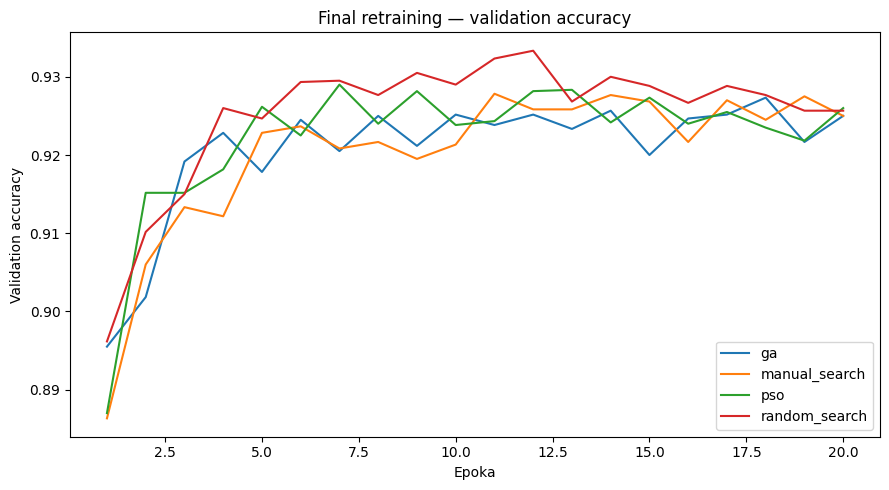

In [ ]:
plt.figure(figsize=(9, 5))

for method, group in final_history_df.groupby("method"):
    plt.plot(group["epoch"], group["val_acc"], label=method)

plt.xlabel("Epoka")
plt.ylabel("Validation accuracy")
plt.title("Final retraining - validation accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## 21. Końcowa tabela do raportu

In [24]:
report_table = final_results_df.merge(
    analysis_df[["method", "total_time_sec"]],
    on="method",
    how="left",
)

report_table = report_table[[
    "method",
    "search_best_val_accuracy",
    "retrain_best_val_accuracy",
    "final_test_accuracy",
    "total_time_sec",
    "num_params",
]].sort_values("final_test_accuracy", ascending=False)

report_table

,method,search_best_val_accuracy,retrain_best_val_accuracy,final_test_accuracy,total_time_sec,num_params
0,pso,0.926167,0.929000,0.9259,929.134573,1644618
1,random_search,0.926000,0.933333,0.9254,1116.439757,1711178
2,manual_search,0.922833,0.927833,0.9252,281.525726,830698
3,ga,0.922833,0.927333,0.9223,926.791974,813802
